<a href="https://colab.research.google.com/github/ggvignesh/Google-Colab-Projects/blob/main/Multi_Stock_Price_Movement_Prediction_using_Real_Time_News_Sentiment_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STEP - 1 : INSTALL LIBRARIES**

In [15]:
!pip install yfinance vaderSentiment pandas numpy matplotlib seaborn plotly requests --quiet
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


**STEP - 2 : IMPORT LIBRARIES**

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import requests
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--'
})

print("✅ All imports successful!")
print(f"📅 Analysis Date: {datetime.now().strftime('%B %d, %Y')}")

✅ All imports successful!
📅 Analysis Date: May 29, 2026


**STEP - 3 : CONFIGURATION**

In [17]:
# ── 8 Stocks to analyze ───────────────────────────────────────
STOCKS = {
    'AAPL':  'Apple',
    'GOOGL': 'Alphabet (Google)',
    'MSFT':  'Microsoft',
    'AMZN':  'Amazon',
    'TSLA':  'Tesla',
    'META':  'Meta',
    'NVDA':  'NVIDIA',
    'NFLX':  'Netflix'
}

# ── Optional: paste your free key from newsapi.org ────────────
NEWS_API_KEY = "fc6bb038b62544d48291043dc8b58646"

# ── Date range ────────────────────────────────────────────────
DAYS_BACK  = 90   # Change to 30 / 60 / 180 as needed
END_DATE   = datetime.now().strftime('%Y-%m-%d')
START_DATE = (datetime.now() - timedelta(days=DAYS_BACK)).strftime('%Y-%m-%d')

# ── Brand colors for each stock ───────────────────────────────
STOCK_COLORS = {
    'AAPL':  '#555555',
    'GOOGL': '#4285F4',
    'MSFT':  '#00A4EF',
    'AMZN':  '#FF9900',
    'TSLA':  '#E82127',
    'META':  '#0866FF',
    'NVDA':  '#76B900',
    'NFLX':  '#E50914'
}

print("✅ Configuration set!")
print(f"📊 Stocks    : {list(STOCKS.keys())}")
print(f"📅 Period    : {START_DATE}  →  {END_DATE}  ({DAYS_BACK} days)")
print(f"📰 News Mode : {'NewsAPI ✅' if NEWS_API_KEY != 'fc6bb038b62544d48291043dc8b58646' else 'yfinance built-in (no key needed) ✅'}")

✅ Configuration set!
📊 Stocks    : ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA', 'META', 'NVDA', 'NFLX']
📅 Period    : 2026-02-28  →  2026-05-29  (90 days)
📰 News Mode : yfinance built-in (no key needed) ✅


**STEP - 4 : FETCH STOCK PRICE DATA**

In [18]:
def fetch_stock_data(tickers_dict, start, end):
    data = {}
    print(f"\n{'='*65}")
    print(f"  DOWNLOADING STOCK PRICE DATA  ({start}  →  {end})")
    print(f"{'='*65}")

    for ticker, company in tickers_dict.items():
        try:
            raw = yf.download(ticker, start=start, end=end,
                              progress=False, auto_adjust=True)

            # Flatten MultiIndex columns if present
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)

            df = raw.copy()
            df['Daily_Return'] = df['Close'].pct_change() * 100
            df['MA7']          = df['Close'].rolling(7).mean()
            df['MA20']         = df['Close'].rolling(20).mean()
            df['Volatility']   = df['Daily_Return'].rolling(7).std()
            df['Cum_Return']   = ((df['Close'] / df['Close'].iloc[0]) - 1) * 100

            data[ticker] = df

            pct = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
            icon = '📈' if pct > 0 else '📉'
            print(f"  {icon}  {ticker:5s} ({company:22s}) | "
                  f"{len(df):3d} days | "
                  f"Latest: ${df['Close'].iloc[-1]:.2f} | "
                  f"Period Return: {pct:+.1f}%")

        except Exception as e:
            print(f"  ❌ {ticker}: Error — {e}")

    print(f"{'='*65}")
    print(f"✅ Price data loaded for {len(data)} stocks.\n")
    return data


price_data = fetch_stock_data(STOCKS, START_DATE, END_DATE)


  DOWNLOADING STOCK PRICE DATA  (2026-02-28  →  2026-05-29)
  📈  AAPL  (Apple                 ) |  62 days | Latest: $312.51 | Period Return: +18.2%
  📈  GOOGL (Alphabet (Google)     ) |  62 days | Latest: $390.13 | Period Return: +27.4%
  📈  MSFT  (Microsoft             ) |  62 days | Latest: $426.99 | Period Return: +7.4%
  📈  AMZN  (Amazon                ) |  62 days | Latest: $274.00 | Period Return: +31.5%
  📈  TSLA  (Tesla                 ) |  62 days | Latest: $442.10 | Period Return: +9.6%
  📉  META  (Meta                  ) |  62 days | Latest: $635.29 | Period Return: -2.7%
  📈  NVDA  (NVIDIA                ) |  62 days | Latest: $214.25 | Period Return: +17.4%
  📉  NFLX  (Netflix               ) |  62 days | Latest: $86.36 | Period Return: -11.1%
✅ Price data loaded for 8 stocks.



**STEP - 5 : FETCH NEWS AND COMPUTE VADER SENTIMENT**

In [19]:
analyzer = SentimentIntensityAnalyzer()

def score_text(text):
    """VADER compound score: +1.0 (most positive) to -1.0 (most negative)."""
    if not text or not isinstance(text, str):
        return 0.0
    return analyzer.polarity_scores(text)['compound']


def get_yf_sentiment(ticker):
    """Pull headlines from yfinance's built-in .news — no API key needed."""
    try:
        news_items = yf.Ticker(ticker).news
    except Exception:
        return pd.DataFrame()

    if not news_items:
        return pd.DataFrame()

    records = []
    for item in news_items:
        content = item.get('content', {})

        # Extract title
        title = ''
        if isinstance(content, dict):
            title = content.get('title', '') or content.get('summary', '')
        if not title:
            title = item.get('title', '')

        # Extract publish timestamp
        pub_time = item.get('providerPublishTime', 0)
        if not pub_time and isinstance(content, dict):
            pub_info = content.get('pubDate', '') or content.get('displayTime', '')
            if pub_info:
                try:
                    pub_time = pd.to_datetime(pub_info).timestamp()
                except Exception:
                    pub_time = 0

        if not title or not pub_time:
            continue

        try:
            date = datetime.fromtimestamp(pub_time).date()
        except Exception:
            continue

        scores = analyzer.polarity_scores(title)
        records.append({
            'date':     date,
            'title':    title,
            'compound': scores['compound'],
            'positive': scores['pos'],
            'negative': scores['neg'],
            'neutral':  scores['neu']
        })

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'])

    return df.groupby('date').agg(
        avg_sentiment=('compound', 'mean'),
        news_count   =('compound', 'count'),
        avg_positive =('positive', 'mean'),
        avg_negative =('negative', 'mean'),
        avg_neutral  =('neutral',  'mean')
    ).reset_index()


def get_newsapi_sentiment(ticker, company, api_key, start, end):
    """Pull news from NewsAPI (free key: newsapi.org). Falls back gracefully."""
    if api_key == 'YOUR_NEWSAPI_KEY':
        return pd.DataFrame()

    params = {
        'q':        f'{ticker} stock OR {company}',
        'from':     start,
        'to':       end,
        'language': 'en',
        'sortBy':   'publishedAt',
        'pageSize': 100,
        'apiKey':   api_key
    }
    try:
        articles = requests.get(
            'https://newsapi.org/v2/everything', params=params, timeout=10
        ).json().get('articles', [])
    except Exception:
        return pd.DataFrame()

    records = []
    for a in articles:
        text = ((a.get('title') or '') + ' ' + (a.get('description') or '')).strip()
        if not text:
            continue
        try:
            date = pd.to_datetime(a['publishedAt']).date()
        except Exception:
            continue
        s = analyzer.polarity_scores(text)
        records.append({'date': date, 'compound': s['compound'],
                        'positive': s['pos'], 'negative': s['neg'], 'neutral': s['neu']})

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'])
    return df.groupby('date').agg(
        avg_sentiment=('compound', 'mean'),
        news_count   =('compound', 'count'),
        avg_positive =('positive', 'mean'),
        avg_negative =('negative', 'mean'),
        avg_neutral  =('neutral',  'mean')
    ).reset_index()


# ── Run for all 8 stocks ──────────────────────────────────────
print(f"\n{'='*65}")
print("  FETCHING NEWS & COMPUTING SENTIMENT SCORES (VADER)")
print(f"{'='*65}")

sentiment_data = {}

for ticker, company in STOCKS.items():
    if NEWS_API_KEY != 'YOUR_NEWSAPI_KEY':
        df     = get_newsapi_sentiment(ticker, company, NEWS_API_KEY, START_DATE, END_DATE)
        source = 'NewsAPI'
        if df.empty:
            df     = get_yf_sentiment(ticker)
            source = 'yfinance'
    else:
        df     = get_yf_sentiment(ticker)
        source = 'yfinance'

    if df.empty:
        df = pd.DataFrame(columns=['date','avg_sentiment','news_count'])

    sentiment_data[ticker] = df

    if not df.empty and 'avg_sentiment' in df.columns:
        avg = df['avg_sentiment'].mean()
        cnt = int(df['news_count'].sum()) if 'news_count' in df.columns else len(df)
        lbl = '🟢 Positive' if avg > 0.05 else ('🔴 Negative' if avg < -0.02 else '🟡 Neutral')
        print(f"  ✅ {ticker:5s} | {source:10s} | Days: {len(df):3d} | "
              f"Articles: {cnt:4d} | Avg Sentiment: {avg:+.4f}  {lbl}")
    else:
        print(f"  ⚠️  {ticker:5s} | No sentiment data retrieved")

print(f"{'='*65}")
print("✅ Sentiment scoring complete!\n")


  FETCHING NEWS & COMPUTING SENTIMENT SCORES (VADER)
  ✅ AAPL  | yfinance   | Days:   3 | Articles:   10 | Avg Sentiment: +0.4447  🟢 Positive
  ✅ GOOGL | yfinance   | Days:   2 | Articles:   10 | Avg Sentiment: +0.1084  🟢 Positive
  ✅ MSFT  | yfinance   | Days:   1 | Articles:   10 | Avg Sentiment: +0.2337  🟢 Positive
  ✅ AMZN  | yfinance   | Days:   1 | Articles:   10 | Avg Sentiment: +0.1294  🟢 Positive
  ✅ TSLA  | yfinance   | Days:   2 | Articles:   10 | Avg Sentiment: +0.2436  🟢 Positive
  ✅ META  | yfinance   | Days:   2 | Articles:   10 | Avg Sentiment: -0.0847  🔴 Negative
  ✅ NVDA  | yfinance   | Days:   2 | Articles:   10 | Avg Sentiment: +0.2117  🟢 Positive
  ✅ NFLX  | yfinance   | Days:   3 | Articles:   10 | Avg Sentiment: -0.0321  🔴 Negative
✅ Sentiment scoring complete!



**STEP - 6 : MERGE PRICE AND SENTIMENT**

In [20]:
def merge_price_sentiment(price_df, sentiment_df):
    df = price_df.copy().reset_index()
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df['Date'] = pd.to_datetime(df['Date'])

    if not sentiment_df.empty and 'date' in sentiment_df.columns:
        sent = sentiment_df.copy()
        sent['date'] = pd.to_datetime(sent['date'])
        df = pd.merge(df, sent, left_on='Date', right_on='date', how='left')
        if 'date' in df.columns:
            df.drop(columns=['date'], inplace=True)
    else:
        df['avg_sentiment'] = 0.0
        df['news_count']    = 0

    df['avg_sentiment']     = df['avg_sentiment'].fillna(0.0)
    df['news_count']        = df['news_count'].fillna(0).astype(int)
    df['rolling_sentiment'] = df['avg_sentiment'].rolling(7, min_periods=1).mean()
    df['sentiment_signal']  = df['avg_sentiment'].apply(
        lambda s: 'Positive' if s > 0.05 else ('Negative' if s < -0.05 else 'Neutral')
    )
    df['next_day_return']   = df['Daily_Return'].shift(-1)
    return df


merged_data = {}
for ticker in STOCKS:
    merged_data[ticker] = merge_price_sentiment(price_data[ticker], sentiment_data[ticker])
    print(f"  ✅ {ticker}: {len(merged_data[ticker])} rows merged")

print("\n✅ All data merged! Ready for visualizations.")
print("\n🔍 Sample — AAPL (first 5 rows):")
cols = ['Date','Close','Daily_Return','MA7','avg_sentiment','news_count','sentiment_signal']
display(merged_data['AAPL'][cols].head())

  ✅ AAPL: 62 rows merged
  ✅ GOOGL: 62 rows merged
  ✅ MSFT: 62 rows merged
  ✅ AMZN: 62 rows merged
  ✅ TSLA: 62 rows merged
  ✅ META: 62 rows merged
  ✅ NVDA: 62 rows merged
  ✅ NFLX: 62 rows merged

✅ All data merged! Ready for visualizations.

🔍 Sample — AAPL (first 5 rows):


,Date,Close,Daily_Return,MA7,avg_sentiment,news_count,sentiment_signal
0,2026-03-02,264.476318,NaN,NaN,0.0,0,Neutral
1,2026-03-03,263.507233,-0.366417,NaN,0.0,0,Neutral
2,2026-03-04,262.278351,-0.466356,NaN,0.0,0,Neutral
3,2026-03-05,260.050415,-0.849455,NaN,0.0,0,Neutral
4,2026-03-06,257.222992,-1.087260,NaN,0.0,0,Neutral


**STEP - 7 : 1ST VISUALIZATION OF PRICE V/S SENTIMENT SCORE**

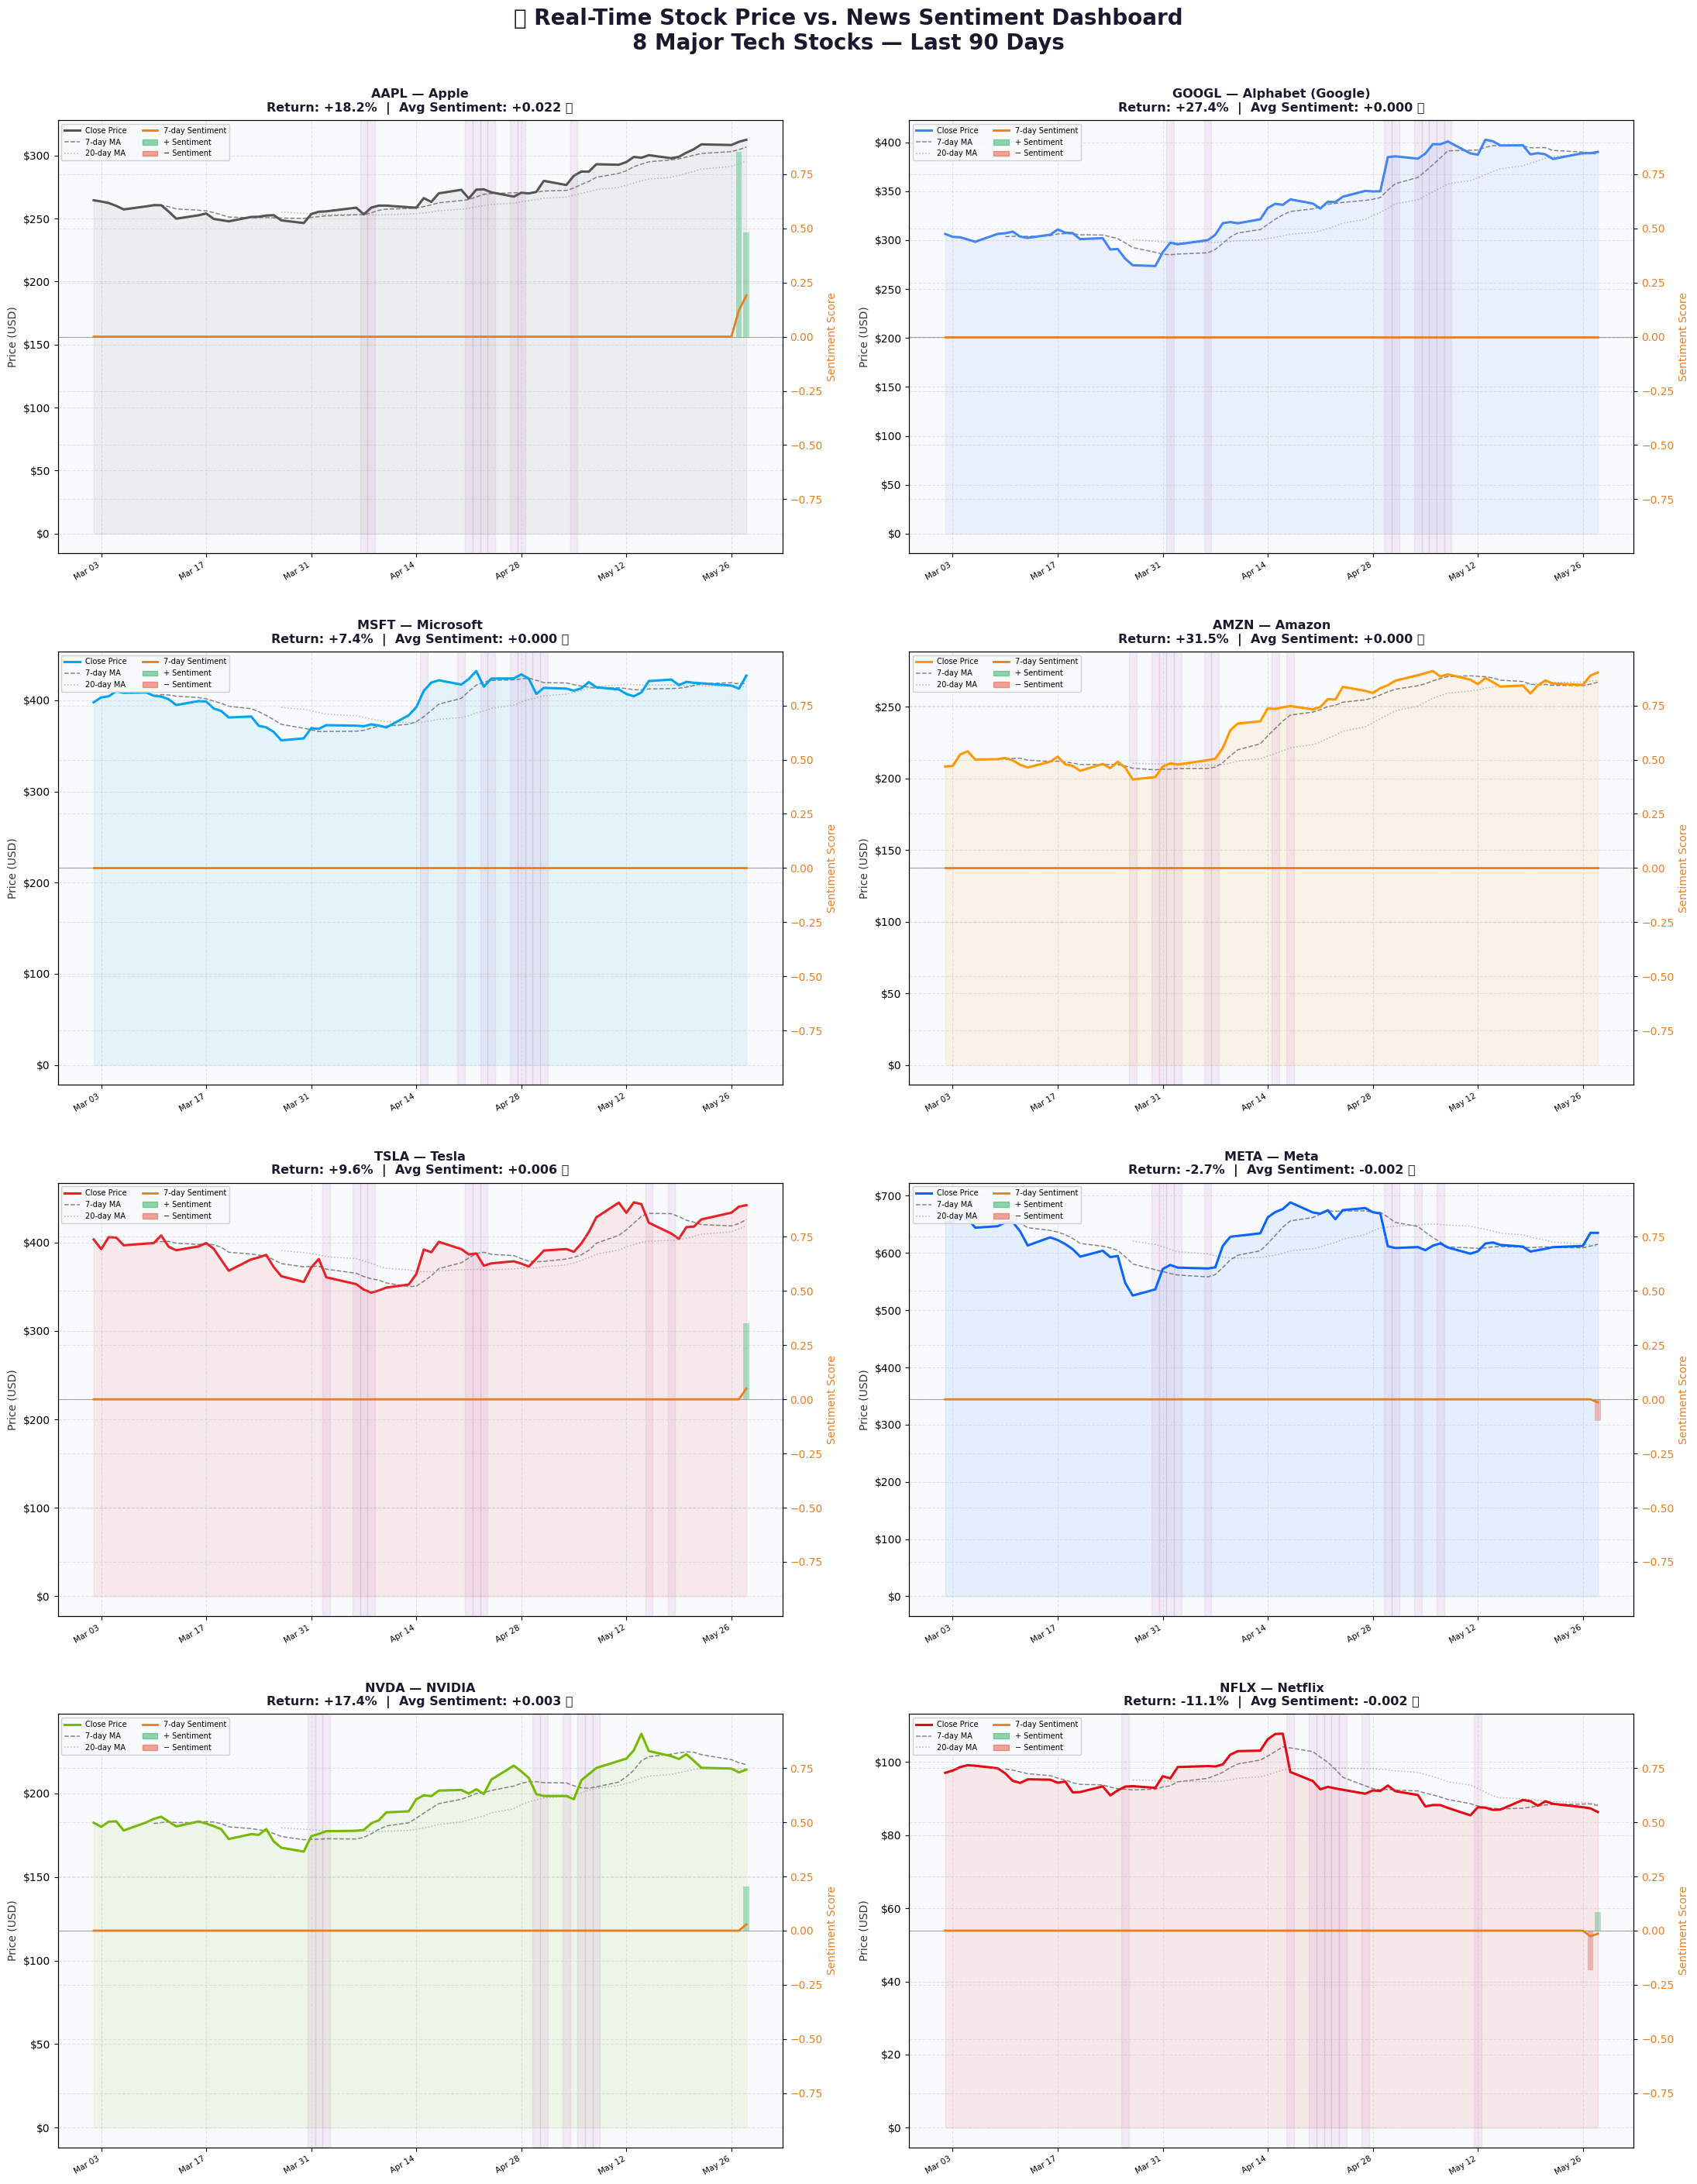

✅ Saved as 'viz1_price_sentiment_dashboard.png'


In [21]:
fig, axes = plt.subplots(4, 2, figsize=(22, 28))
fig.suptitle(
    '📈 Real-Time Stock Price vs. News Sentiment Dashboard\n'
    '8 Major Tech Stocks — Last 90 Days',
    fontsize=20, fontweight='bold', y=1.005, color='#1a1a2e'
)

for idx, (ticker, company) in enumerate(STOCKS.items()):
    row, col = divmod(idx, 2)
    ax1  = axes[row][col]
    df   = merged_data[ticker]
    color = STOCK_COLORS[ticker]

    # Left axis — Price
    ax1.fill_between(df['Date'], df['Close'], alpha=0.08, color=color)
    ax1.plot(df['Date'], df['Close'],  color=color,     linewidth=2.2, label='Close Price', zorder=3)
    ax1.plot(df['Date'], df['MA7'],    color='#555555', linewidth=1.1, linestyle='--', alpha=0.7, label='7-day MA',  zorder=2)
    ax1.plot(df['Date'], df['MA20'],   color='#999999', linewidth=1.1, linestyle=':',  alpha=0.7, label='20-day MA', zorder=2)

    ax1.set_ylabel('Price (USD)', fontsize=10, color='#333333')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7.5)

    # Right axis — Sentiment
    ax2 = ax1.twinx()
    bar_colors = ['#27ae60' if s > 0.05 else ('#e74c3c' if s < -0.05 else '#95a5a6')
                  for s in df['avg_sentiment']]
    ax2.bar(df['Date'], df['avg_sentiment'], color=bar_colors, alpha=0.35, width=0.8, zorder=1)
    ax2.plot(df['Date'], df['rolling_sentiment'], color='#e67e22', linewidth=2.0, label='7-day Sentiment', zorder=4)
    ax2.axhline(y=0, color='#777777', linewidth=0.8, alpha=0.6)
    ax2.set_ylim(-1.0, 1.0)
    ax2.set_ylabel('Sentiment Score', fontsize=10, color='#e67e22')
    ax2.tick_params(axis='y', labelcolor='#e67e22')
    ax2.set_yticks([-0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75])

    # Shade high-volatility days
    vol_threshold = df['Volatility'].quantile(0.85)
    for _, hv in df[df['Volatility'] > vol_threshold].iterrows():
        ax1.axvspan(hv['Date'] - timedelta(hours=12),
                    hv['Date'] + timedelta(hours=12),
                    alpha=0.06, color='purple')

    # Title
    period_ret = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
    avg_sent   = df['avg_sentiment'].mean()
    sent_icon  = '🟢' if avg_sent > 0.05 else ('🔴' if avg_sent < -0.05 else '🟡')

    ax1.set_title(
        f'{ticker} — {company}\n'
        f'Return: {period_ret:+.1f}%  |  Avg Sentiment: {avg_sent:+.3f} {sent_icon}',
        fontsize=11.5, fontweight='bold', color='#1a1a2e', pad=8
    )

    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    pos_p = mpatches.Patch(color='#27ae60', alpha=0.5, label='+ Sentiment')
    neg_p = mpatches.Patch(color='#e74c3c', alpha=0.5, label='− Sentiment')
    ax1.legend(handles=lines1 + lines2 + [pos_p, neg_p],
               loc='upper left', fontsize=7, framealpha=0.9, ncol=2, borderpad=0.4)
    ax1.set_facecolor('#f8fafc')

plt.tight_layout(h_pad=3.5, w_pad=2)
plt.savefig('viz1_price_sentiment_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'viz1_price_sentiment_dashboard.png'")

**STEP - 8 : 2ND VISUALIZATION CORRELATION HEATMAP**

🔍 Computing correlation matrix...

        Same-Day  Next-Day (Predictive)  2-Day Ahead  1-Day Lagged  Rolling 7d Sentiment
Ticker                                                                                  
AAPL      0.0585                 0.0238          NaN        0.0238                0.0496
GOOGL        NaN                    NaN          NaN           NaN                   NaN
MSFT         NaN                    NaN          NaN           NaN                   NaN
AMZN         NaN                    NaN          NaN           NaN                   NaN
TSLA      0.0107                    NaN          NaN           NaN                0.0107
META     -0.0009                    NaN          NaN           NaN               -0.0009
NVDA      0.0283                    NaN          NaN           NaN                0.0283
NFLX     -0.0145                 0.0627          NaN        0.0627                0.0421


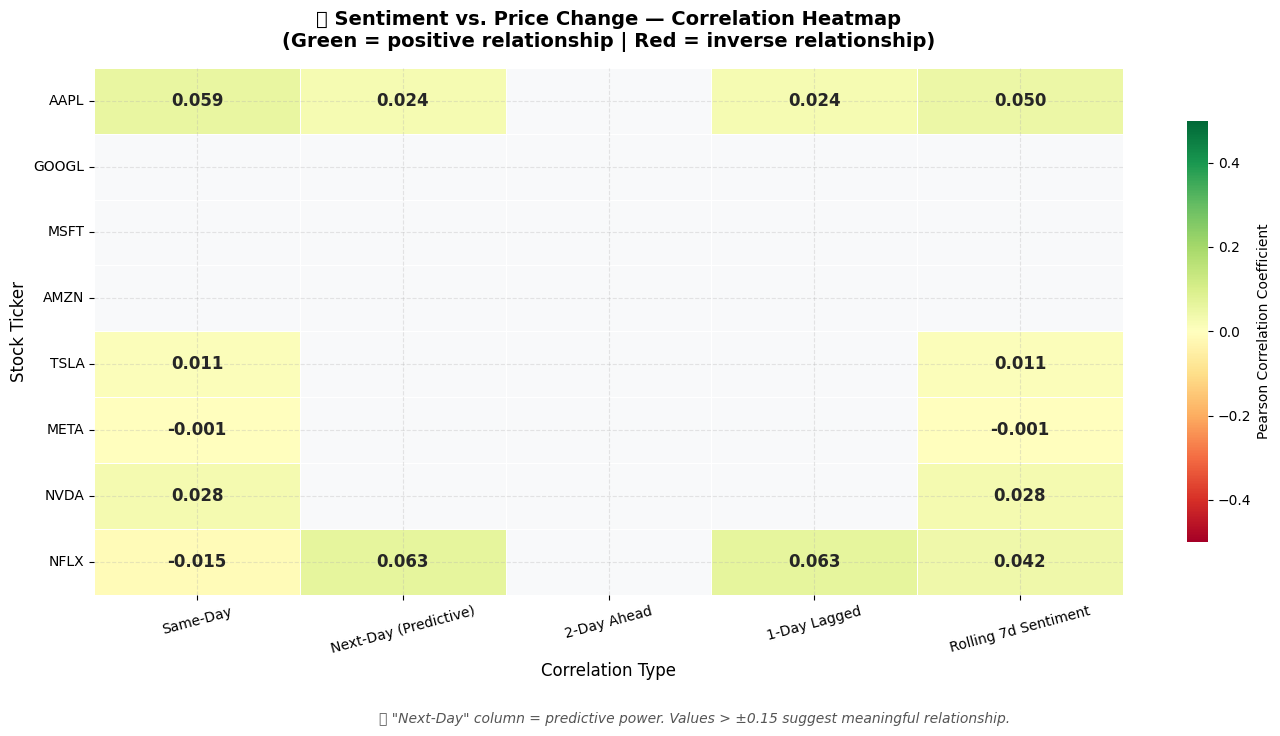

✅ Saved as 'viz2_correlation_heatmap.png'


In [22]:
print("🔍 Computing correlation matrix...\n")

corr_rows = []
for ticker, company in STOCKS.items():
    df = merged_data[ticker].dropna(subset=['Daily_Return'])
    corr_rows.append({
        'Ticker':                ticker,
        'Same-Day':              round(df['avg_sentiment'].corr(df['Daily_Return']),          4),
        'Next-Day (Predictive)': round(df['avg_sentiment'].corr(df['next_day_return']),        4),
        '2-Day Ahead':           round(df['avg_sentiment'].corr(df['Daily_Return'].shift(-2)), 4),
        '1-Day Lagged':          round(df['avg_sentiment'].shift(1).corr(df['Daily_Return']), 4),
        'Rolling 7d Sentiment':  round(df['rolling_sentiment'].corr(df['Daily_Return']),       4)
    })

corr_df = pd.DataFrame(corr_rows).set_index('Ticker')
print(corr_df.to_string())

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    corr_df,
    annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.6, linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax,
    cbar_kws={'label': 'Pearson Correlation Coefficient', 'shrink': 0.8}
)
ax.set_title(
    '🔗 Sentiment vs. Price Change — Correlation Heatmap\n'
    '(Green = positive relationship | Red = inverse relationship)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Correlation Type', fontsize=12)
ax.set_ylabel('Stock Ticker', fontsize=12)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)
fig.text(0.5, -0.04,
         '📌 "Next-Day" column = predictive power. Values > ±0.15 suggest meaningful relationship.',
         ha='center', fontsize=10, style='italic', color='#555555')

plt.tight_layout()
plt.savefig('viz2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'viz2_correlation_heatmap.png'")

**STEP - 9 : 3RD VISUALIZATION SENTIMENT COMPARISON BAR CHART**

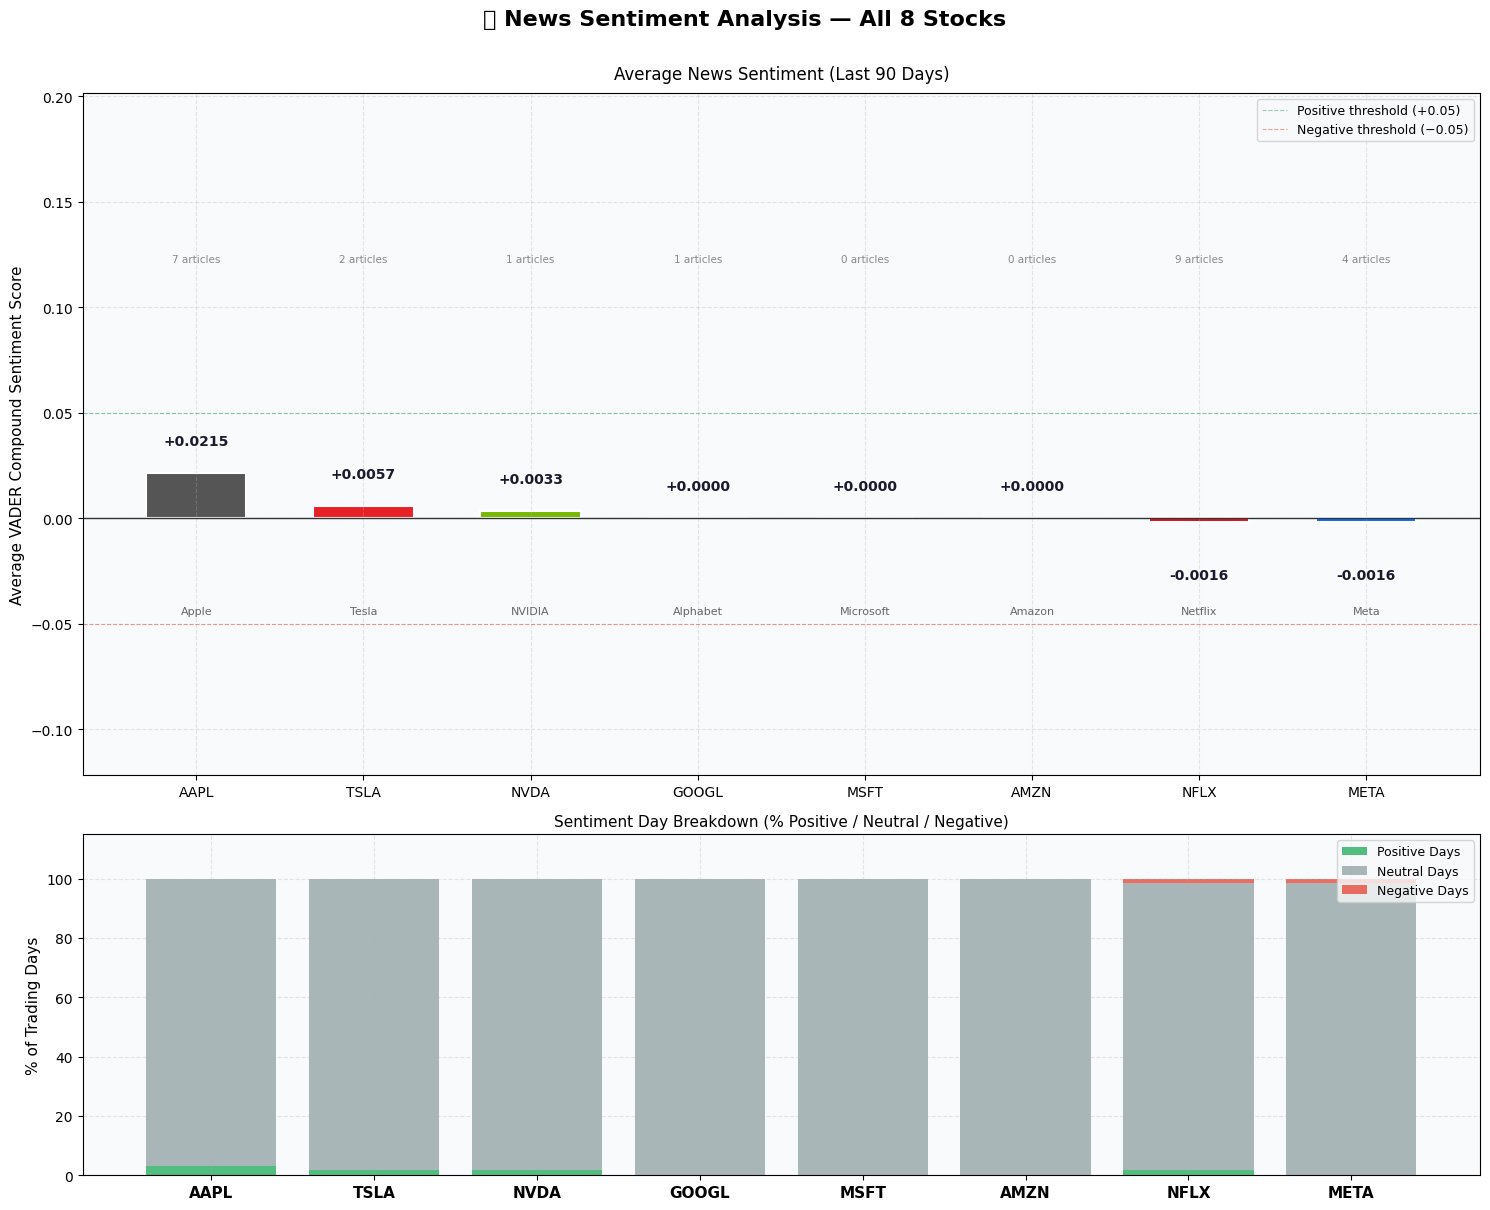

✅ Saved as 'viz3_sentiment_comparison.png'


In [23]:
# Build per-stock summary stats
summary_stats = {}
for ticker in STOCKS:
    df  = merged_data[ticker]
    avg = df['avg_sentiment'].mean()
    tot = len(df)
    summary_stats[ticker] = {
        'company':  STOCKS[ticker],
        'avg_sent': avg,
        'pos_pct':  (df['avg_sentiment'] > 0.05).sum()  / tot * 100,
        'neg_pct':  (df['avg_sentiment'] < -0.05).sum() / tot * 100,
        'neu_pct':  ((df['avg_sentiment'] >= -0.05) & (df['avg_sentiment'] <= 0.05)).sum() / tot * 100,
        'articles': int(df['news_count'].sum())
    }

sorted_t  = sorted(summary_stats, key=lambda t: summary_stats[t]['avg_sent'], reverse=True)
avg_vals  = [summary_stats[t]['avg_sent'] for t in sorted_t]
companies = [summary_stats[t]['company']  for t in sorted_t]
b_colors  = [STOCK_COLORS[t]              for t in sorted_t]

fig, (ax_main, ax_stack) = plt.subplots(2, 1, figsize=(15, 12),
                                         gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('📰 News Sentiment Analysis — All 8 Stocks',
             fontsize=16, fontweight='bold', y=1.005)

# Top: avg sentiment bars
bars = ax_main.bar(sorted_t, avg_vals, color=b_colors, edgecolor='white', linewidth=1.5, width=0.6)
ax_main.axhline(y=0,     color='#333333', linewidth=1.0)
ax_main.axhline(y=0.05,  color='#27ae60', linewidth=0.8, linestyle='--', alpha=0.5, label='Positive threshold (+0.05)')
ax_main.axhline(y=-0.05, color='#e74c3c', linewidth=0.8, linestyle='--', alpha=0.5, label='Negative threshold (−0.05)')

for bar, val, ticker, co in zip(bars, avg_vals, sorted_t, companies):
    ypos = val + 0.012 if val >= 0 else val - 0.022
    ax_main.text(bar.get_x() + bar.get_width()/2, ypos,
                 f'{val:+.4f}', ha='center',
                 va='bottom' if val >= 0 else 'top',
                 fontsize=10, fontweight='bold', color='#1a1a2e')
    ax_main.text(bar.get_x() + bar.get_width()/2, min(avg_vals) - 0.04,
                 co.split('(')[0].strip(),
                 ha='center', va='top', fontsize=8, color='#666666')
    ax_main.text(bar.get_x() + bar.get_width()/2, max(avg_vals) + 0.10,
                 f"{summary_stats[ticker]['articles']} articles",
                 ha='center', fontsize=7.5, color='#888888')

ax_main.set_ylim(min(avg_vals) - 0.12, max(avg_vals) + 0.18)
ax_main.set_ylabel('Average VADER Compound Sentiment Score', fontsize=11)
ax_main.set_title('Average News Sentiment (Last 90 Days)', fontsize=12, pad=10)
ax_main.legend(fontsize=9, loc='upper right')
ax_main.set_facecolor('#f8fafc')

# Bottom: stacked positive/neutral/negative breakdown
x        = np.arange(len(sorted_t))
pos_vals = [summary_stats[t]['pos_pct'] for t in sorted_t]
neu_vals = [summary_stats[t]['neu_pct'] for t in sorted_t]
neg_vals = [summary_stats[t]['neg_pct'] for t in sorted_t]

ax_stack.bar(x, pos_vals, label='Positive Days', color='#27ae60', alpha=0.8)
ax_stack.bar(x, neu_vals, bottom=pos_vals, label='Neutral Days', color='#95a5a6', alpha=0.8)
ax_stack.bar(x, neg_vals,
             bottom=[p + n for p, n in zip(pos_vals, neu_vals)],
             label='Negative Days', color='#e74c3c', alpha=0.8)

ax_stack.set_xticks(x)
ax_stack.set_xticklabels(sorted_t, fontsize=11, fontweight='bold')
ax_stack.set_ylabel('% of Trading Days', fontsize=11)
ax_stack.set_title('Sentiment Day Breakdown (% Positive / Neutral / Negative)', fontsize=11)
ax_stack.set_ylim(0, 115)
ax_stack.legend(loc='upper right', fontsize=9)
ax_stack.set_facecolor('#f8fafc')

for i, (p, n, ne) in enumerate(zip(pos_vals, neu_vals, neg_vals)):
    if p  > 5: ax_stack.text(i, p/2,      f'{p:.0f}%',  ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if ne > 5: ax_stack.text(i, p + ne/2, f'{ne:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('viz3_sentiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'viz3_sentiment_comparison.png'")

**STEP - 10 : 4TH VISUALIZATION CORRELATION ANALYSIS**

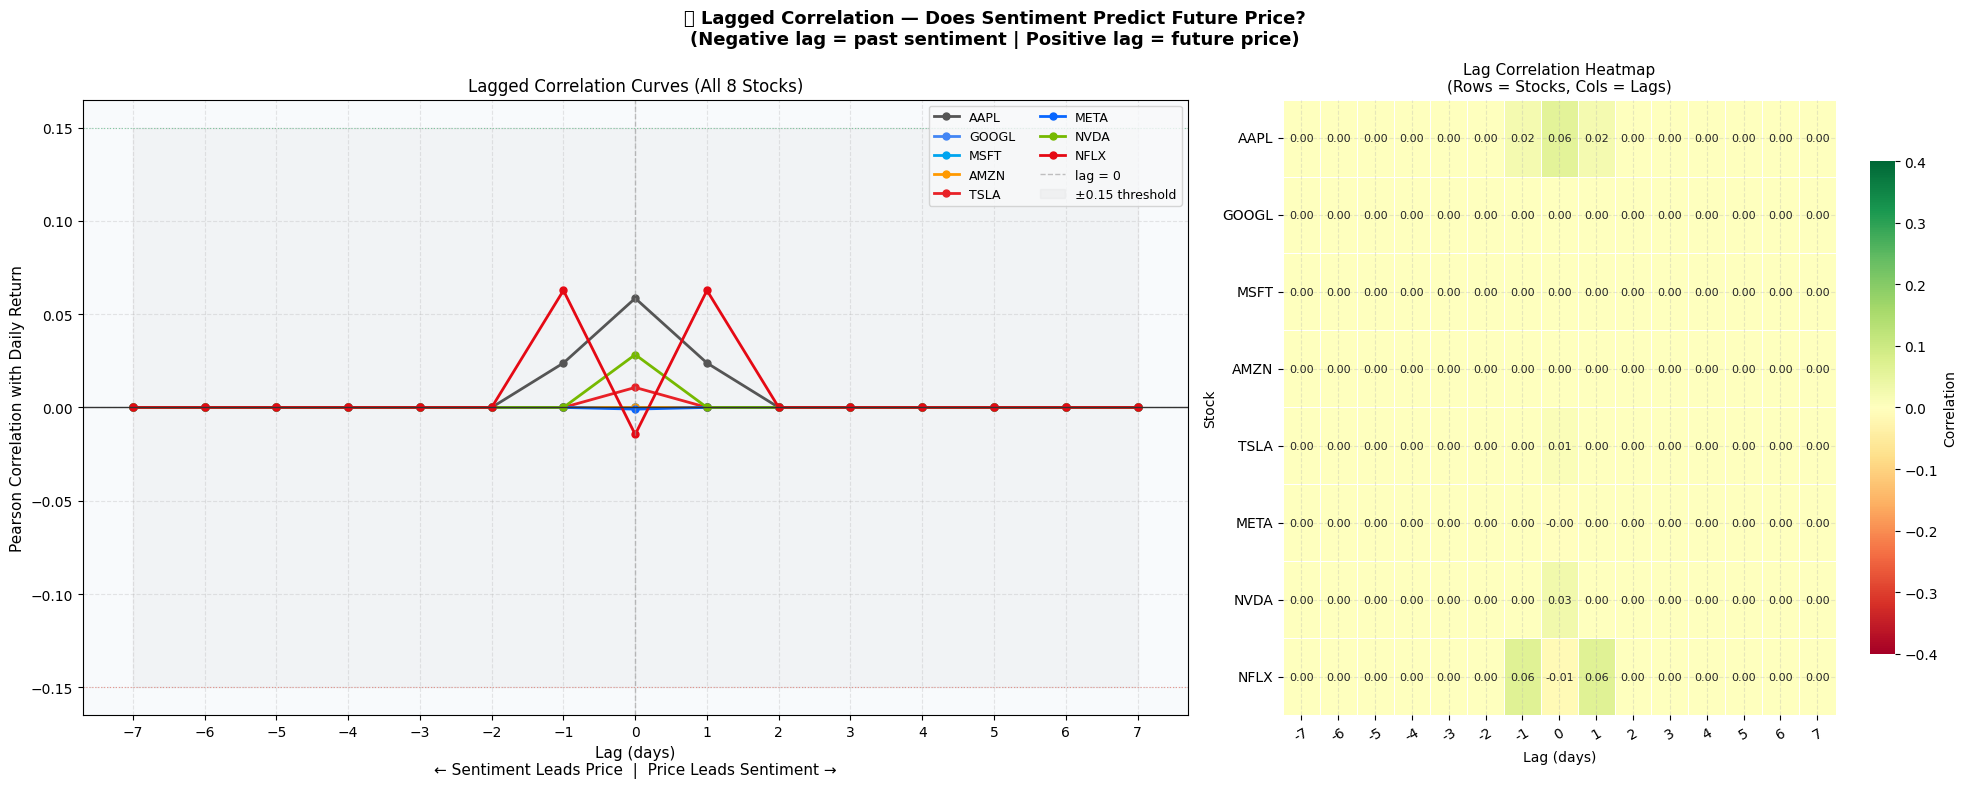

✅ Saved as 'viz4_lagged_correlation.png'


In [24]:
lag_range = range(-7, 8)

fig, (ax_main, ax_heat) = plt.subplots(
    1, 2, figsize=(20, 8),
    gridspec_kw={'width_ratios': [1.6, 1]}
)
fig.suptitle(
    '📡 Lagged Correlation — Does Sentiment Predict Future Price?\n'
    '(Negative lag = past sentiment | Positive lag = future price)',
    fontsize=13, fontweight='bold'
)

lag_results = {}

for ticker in STOCKS:
    df = merged_data[ticker].dropna(subset=['avg_sentiment', 'Daily_Return'])
    lags, corrs = [], []

    for lag in lag_range:
        if lag == 0:
            corr = df['avg_sentiment'].corr(df['Daily_Return'])
        elif lag > 0:   # today's sentiment vs return N days later
            corr = df['avg_sentiment'].corr(df['Daily_Return'].shift(-lag))
        else:           # sentiment N days ago vs today's return
            corr = df['avg_sentiment'].shift(-lag).corr(df['Daily_Return'])

        lags.append(lag)
        corrs.append(round(corr, 4) if pd.notna(corr) else 0.0)

    lag_results[ticker] = dict(zip(lags, corrs))
    ax_main.plot(lags, corrs, marker='o', linewidth=2.0, markersize=5,
                 label=ticker, color=STOCK_COLORS[ticker])

ax_main.axhline(y=0,    color='#333333', linewidth=1.0)
ax_main.axvline(x=0,    color='#999999', linewidth=1.0, linestyle='--', alpha=0.6, label='lag = 0')
ax_main.axhline(y=0.15, color='#27ae60', linewidth=0.8, linestyle=':', alpha=0.5)
ax_main.axhline(y=-0.15,color='#e74c3c', linewidth=0.8, linestyle=':', alpha=0.5)
ax_main.fill_between(list(lag_range), -0.15, 0.15, alpha=0.05, color='gray', label='±0.15 threshold')

ax_main.set_xlabel('Lag (days)\n← Sentiment Leads Price  |  Price Leads Sentiment →', fontsize=11)
ax_main.set_ylabel('Pearson Correlation with Daily Return', fontsize=11)
ax_main.set_title('Lagged Correlation Curves (All 8 Stocks)', fontsize=12)
ax_main.legend(loc='upper right', fontsize=9, ncol=2)
ax_main.set_xticks(list(lag_range))
ax_main.set_facecolor('#f8fafc')

# Heatmap version
lag_df = pd.DataFrame(lag_results, index=list(lag_range)).T
lag_df.columns.name = 'Lag'
lag_df.index.name   = 'Stock'

sns.heatmap(lag_df, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-0.4, vmax=0.4,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, ax=ax_heat,
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
ax_heat.set_title('Lag Correlation Heatmap\n(Rows = Stocks, Cols = Lags)', fontsize=11)
ax_heat.set_xlabel('Lag (days)', fontsize=10)
ax_heat.tick_params(axis='y', rotation=0)
ax_heat.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('viz4_lagged_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'viz4_lagged_correlation.png'")

**STEP - 11 : 5TH VISUALIZATION CUMULATIVE RETURNS AND SENTIMENT BACKGROUND**

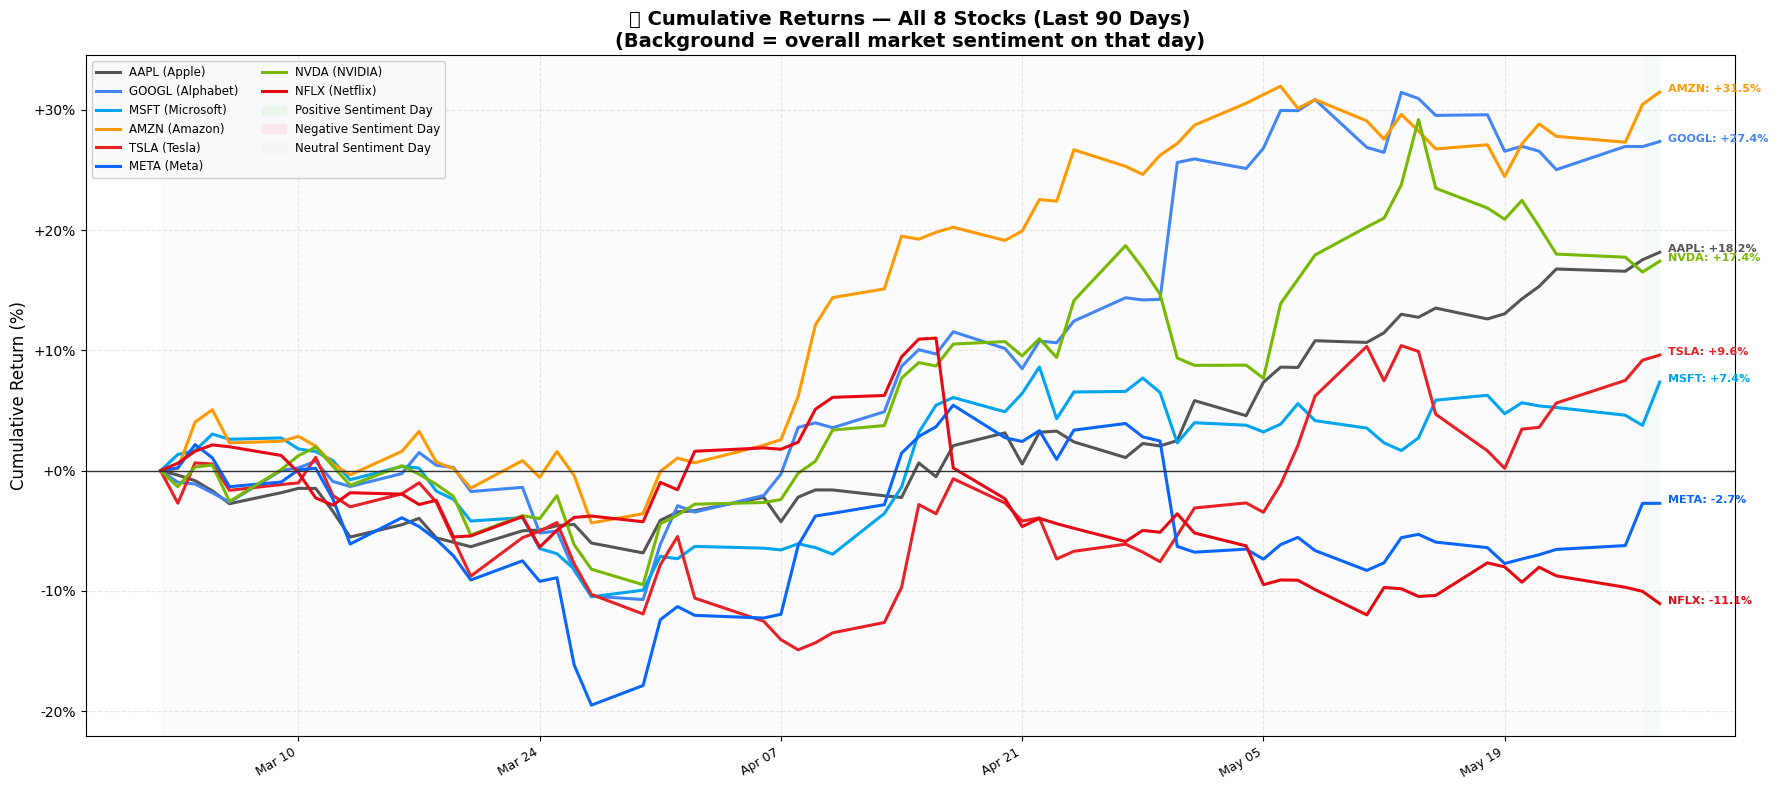

✅ Saved as 'viz5_cumulative_returns.png'


In [25]:
fig, ax = plt.subplots(figsize=(18, 8))

# Compute daily average sentiment across all 8 stocks
all_dates = sorted(set(d for t in STOCKS for d in merged_data[t]['Date'].tolist()))

market_sentiment = []
for d in all_dates:
    vals = []
    for t in STOCKS:
        row = merged_data[t][merged_data[t]['Date'] == d]
        if not row.empty:
            vals.append(float(row['avg_sentiment'].iloc[0]))
    market_sentiment.append(np.mean(vals) if vals else 0.0)

# Background shading by sentiment
for i, (d, sent) in enumerate(zip(all_dates[:-1], market_sentiment[:-1])):
    color = '#e8f5e9' if sent > 0.05 else ('#fce4ec' if sent < -0.05 else '#f5f5f5')
    ax.axvspan(d, all_dates[i + 1], alpha=0.4, color=color, linewidth=0)

# Plot each stock's cumulative return
for ticker, company in STOCKS.items():
    df = merged_data[ticker]
    ax.plot(df['Date'], df['Cum_Return'],
            color=STOCK_COLORS[ticker], linewidth=2.2,
            label=f"{ticker} ({company.split('(')[0].strip()})")
    last = df.dropna(subset=['Cum_Return']).iloc[-1]
    ax.annotate(f"{ticker}: {last['Cum_Return']:+.1f}%",
                xy=(last['Date'], last['Cum_Return']),
                xytext=(6, 0), textcoords='offset points',
                fontsize=8, color=STOCK_COLORS[ticker], fontweight='bold')

ax.axhline(y=0, color='#333333', linewidth=1.0)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)

green_p = mpatches.Patch(color='#e8f5e9', alpha=0.8, label='Positive Sentiment Day')
red_p   = mpatches.Patch(color='#fce4ec', alpha=0.8, label='Negative Sentiment Day')
gray_p  = mpatches.Patch(color='#f5f5f5', alpha=0.8, label='Neutral Sentiment Day')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [green_p, red_p, gray_p],
          loc='upper left', fontsize=8.5, ncol=2, framealpha=0.95)

ax.set_title(
    '📊 Cumulative Returns — All 8 Stocks (Last 90 Days)\n'
    '(Background = overall market sentiment on that day)',
    fontsize=14, fontweight='bold'
)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax.set_facecolor('white')

plt.tight_layout()
plt.savefig('viz5_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'viz5_cumulative_returns.png'")

**STEP - 12 : FINAL SUMMARY TABLE**

In [26]:
from IPython.display import display

print("\n" + "="*85)
print("   📊 COMPLETE ANALYSIS SUMMARY — 8-STOCK SENTIMENT vs. PRICE")
print("="*85)

rows = []
for ticker, company in STOCKS.items():
    df       = merged_data[ticker]
    pret     = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
    avg_sent = df['avg_sentiment'].mean()
    corr_sd  = df['avg_sentiment'].corr(df['Daily_Return'])
    corr_nd  = df['avg_sentiment'].corr(df['next_day_return'])

    rows.append({
        'Ticker':         ticker,
        'Company':        company.split('(')[0].strip(),
        'Latest Price':   f"${df['Close'].iloc[-1]:.2f}",
        '90-Day Return':  f"{pret:+.2f}%",
        'Trend':          '📈 Gain' if pret > 0 else '📉 Loss',
        'Avg Sentiment':  f"{avg_sent:+.4f}",
        'Sentiment':      '🟢 Positive' if avg_sent > 0.05 else ('🔴 Negative' if avg_sent < -0.05 else '🟡 Neutral'),
        'Same-Day Corr':  f"{corr_sd:+.4f}",
        'Next-Day Corr':  f"{corr_nd:+.4f}",
        'Total Articles': int(df['news_count'].sum()),
        '_pret':          pret        # hidden numeric column for sorting
    })

summary_df = pd.DataFrame(rows).drop(columns=['_pret'])
display(summary_df)

print("\n" + "-"*85)
best_sent = max(rows, key=lambda r: float(r['Avg Sentiment']))
best_ret  = max(rows, key=lambda r: r['_pret'])          # ✅ use numeric value directly
most_news = max(rows, key=lambda r: r['Total Articles'])

print(f"  🏆 Most Positive Sentiment : {best_sent['Ticker']}  ({best_sent['Avg Sentiment']})")
print(f"  📈 Best 90-Day Return      : {best_ret['Ticker']}  ({best_ret['90-Day Return']})")
print(f"  📰 Most News Coverage      : {most_news['Ticker']}  ({most_news['Total Articles']} articles)")
print("="*85)
print("\n✅ Analysis Complete! Download charts from Files panel (left sidebar) → right-click → Download")


   📊 COMPLETE ANALYSIS SUMMARY — 8-STOCK SENTIMENT vs. PRICE


,Ticker,Company,Latest Price,90-Day Return,Trend,Avg Sentiment,Sentiment,Same-Day Corr,Next-Day Corr,Total Articles
0,AAPL,Apple,$312.51,+18.16%,📈 Gain,+0.0215,🟡 Neutral,+0.0585,+0.0248,7
1,GOOGL,Alphabet,$390.13,+27.37%,📈 Gain,+0.0000,🟡 Neutral,+nan,+nan,1
2,MSFT,Microsoft,$426.99,+7.37%,📈 Gain,+0.0000,🟡 Neutral,+nan,+nan,0
3,AMZN,Amazon,$274.00,+31.48%,📈 Gain,+0.0000,🟡 Neutral,+nan,+nan,0
4,TSLA,Tesla,$442.10,+9.62%,📈 Gain,+0.0057,🟡 Neutral,+0.0107,+nan,2
5,META,Meta,$635.29,-2.71%,📉 Loss,-0.0016,🟡 Neutral,-0.0009,+nan,4
6,NVDA,NVIDIA,$214.25,+17.42%,📈 Gain,+0.0033,🟡 Neutral,+0.0283,+nan,1
7,NFLX,Netflix,$86.36,-11.05%,📉 Loss,-0.0016,🟡 Neutral,-0.0145,+0.0635,9



-------------------------------------------------------------------------------------
  🏆 Most Positive Sentiment : AAPL  (+0.0215)
  📈 Best 90-Day Return      : AMZN  (+31.48%)
  📰 Most News Coverage      : NFLX  (9 articles)

✅ Analysis Complete! Download charts from Files panel (left sidebar) → right-click → Download
